## Analyzing Covariance Matrices of the simulations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import sys

esmDMS_DIR = "/Users/dylanwells/popDMS/esmDMS"

sys.path.insert(0, esmDMS_DIR)
from esmdmsfunctions import (
    get_eigenvector_simulation_results,
    get_simulation_results,
    generate_selection, gaussian_selection, zero_selection,
    z_normalize, load_final_df,
)
from scipy.stats import pearsonr


In [ ]:
import os

# ── Paths to analyse (name → directory containing layer0/, layer1/, … subdirs)
comb_path = esmDMS_DIR + "/data/bg_bf_comb_data"
bg_path   = esmDMS_DIR + "/data/inference_data/BG505"
bf_path   = esmDMS_DIR + "/data/inference_results"

PATHS = {
    "comb":  comb_path,
    "BG505": bg_path,
    "BF520": bf_path,
}

# ── Layers to analyze
LAYERS = [12, 18]

# ── Simulation parameters
N_GENS      = 1000      # number of generations to simulate
SAVE_EVERY  = 1       # save counts every N generations
FITNESS_FN  = 'exp'   # 'plus1' or 'exp'

# ── Eigenvector / PCA parameters
VARIANCE_EXPLAINED_CUTOFF = 0.8   # keep PCs that together explain this fraction of variance
WEIGHT_BY_INITIAL_FREQ    = False  # weight covariance matrix by pre-selection counts

# ── Selection function (generate_selection, gaussian_selection, or zero_selection)
SEL_FUNC = gaussian_selection

# ── Inference flags
RUN_INFERENCE    = True
RUN_GAMMA        = False
CALC_ERROR_BARS  = False
INFER_IGNORED    = True


Dataset: comb  |  get_simulation_results, method=fullcov
Running layer 12...
  Layer 12: running simulation...
  Layer 12: simulation ran for 30 saved generations.
  Layer 12: running inference...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...


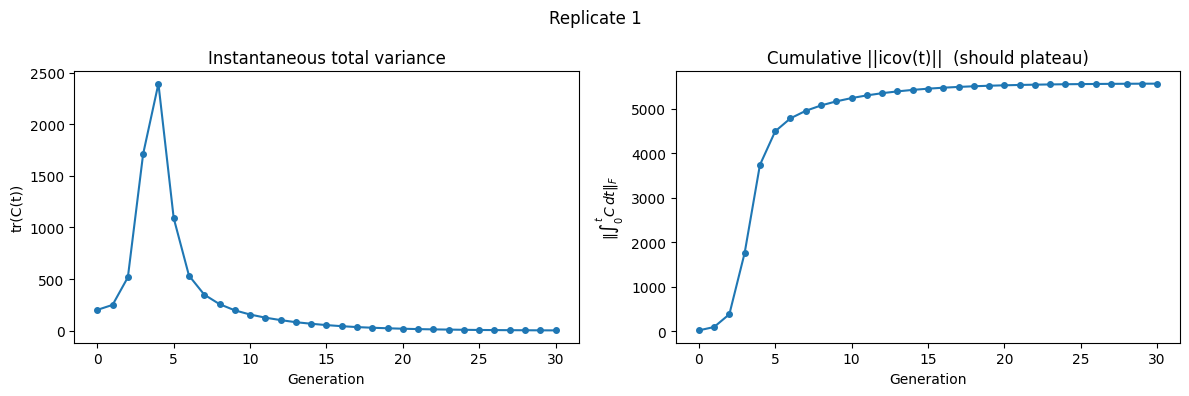

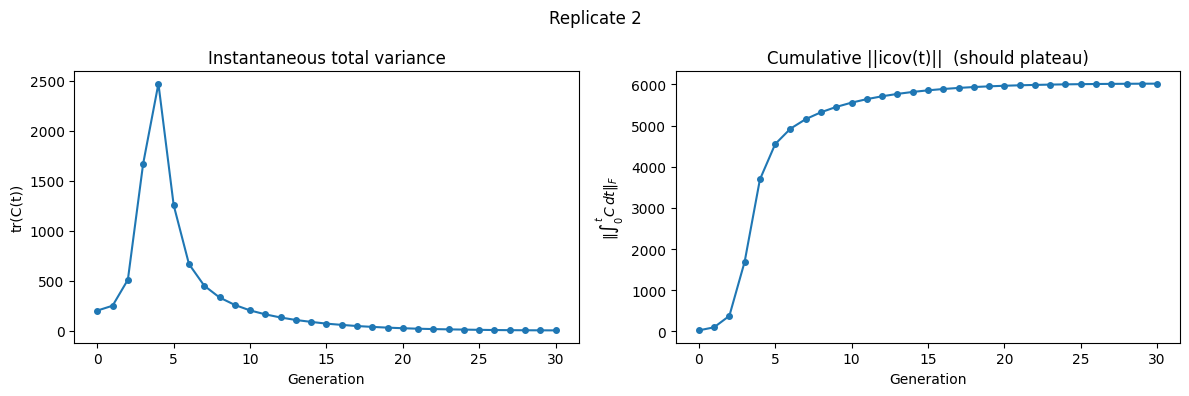

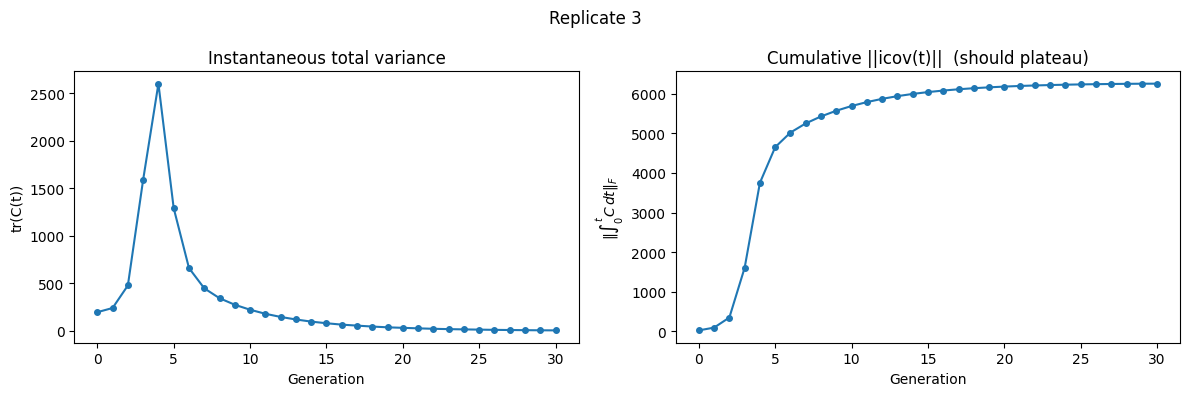

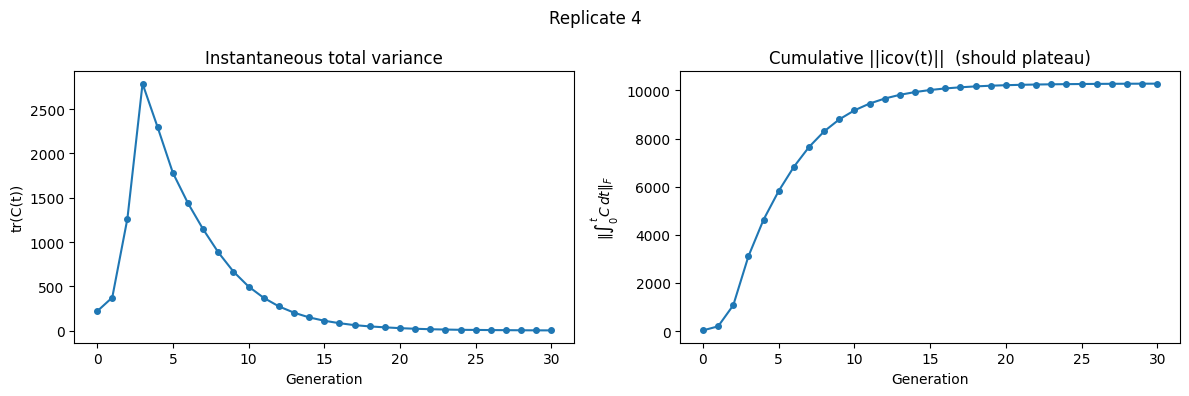

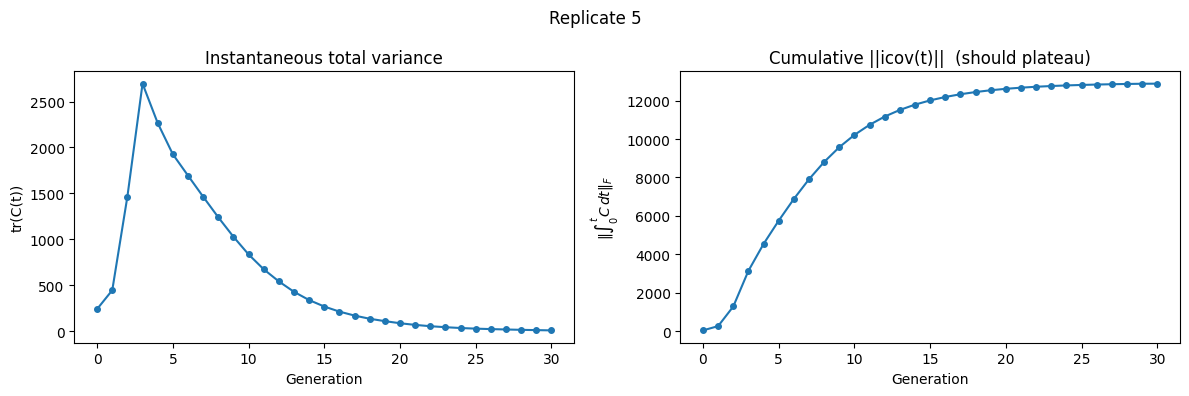

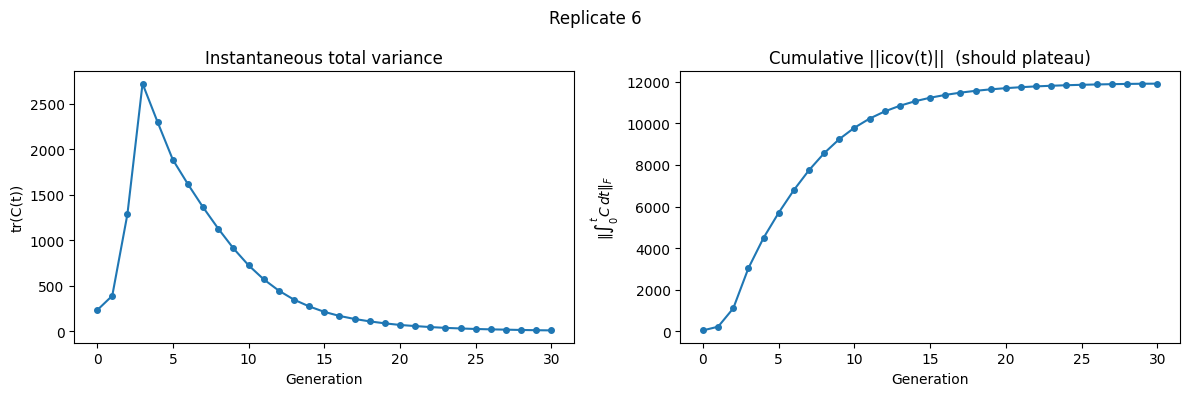

Running layer 18...
  Layer 18: running simulation...
  Layer 18: simulation ran for 30 saved generations.
  Layer 18: running inference...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...


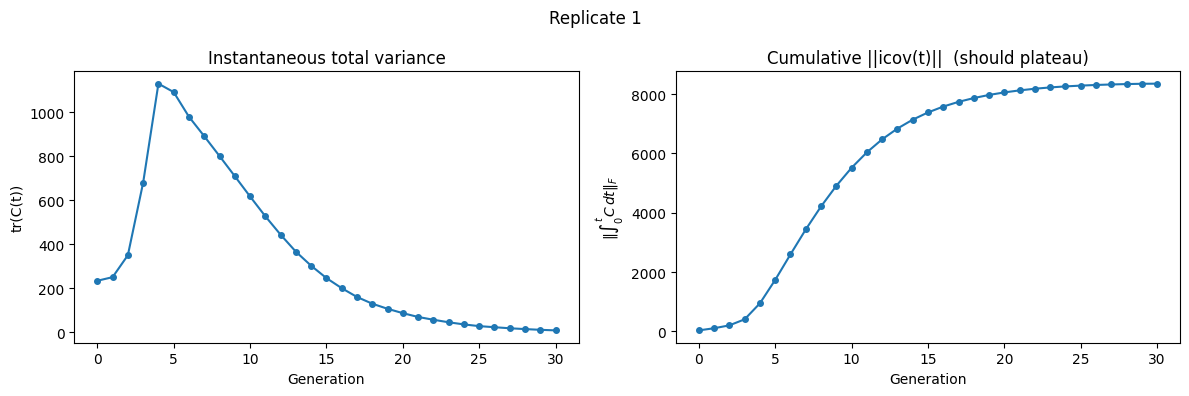

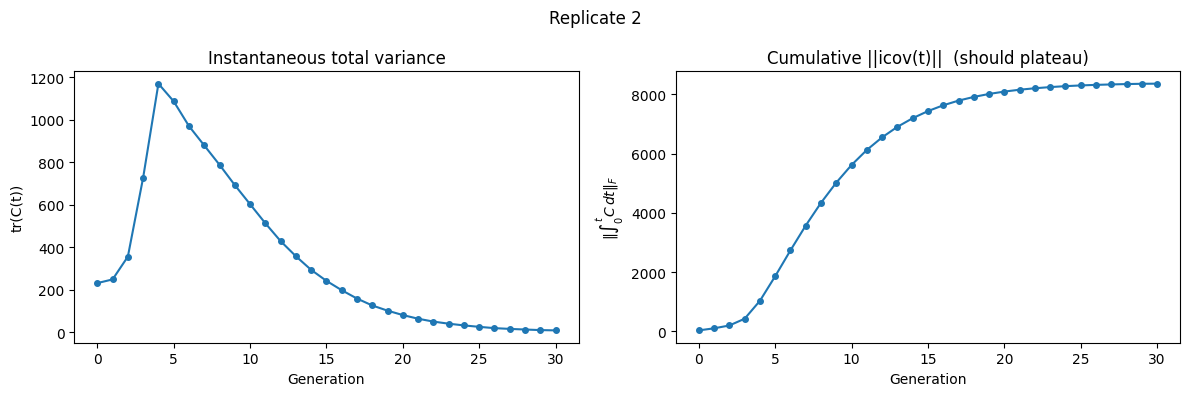

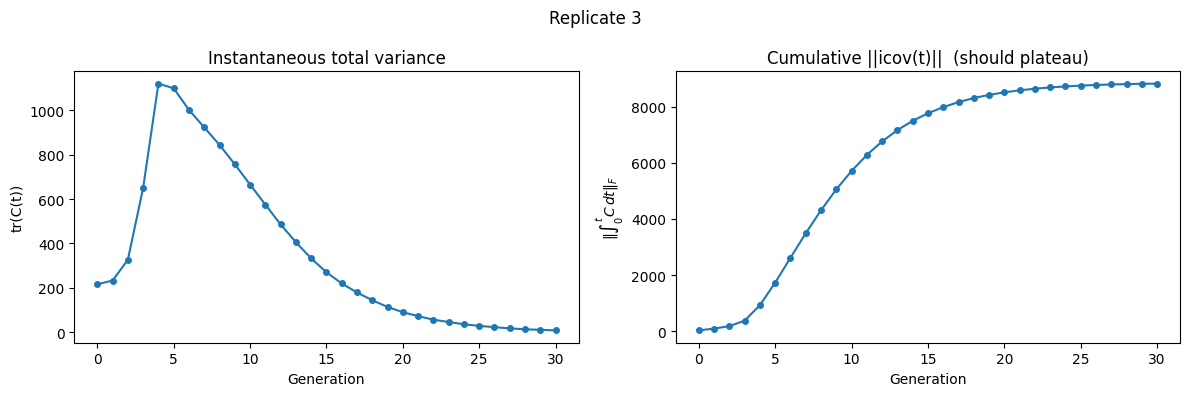

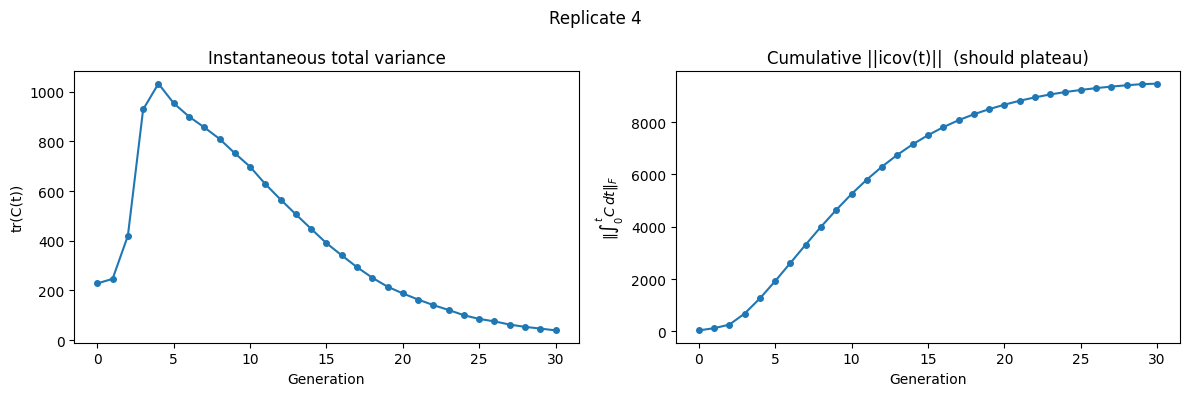

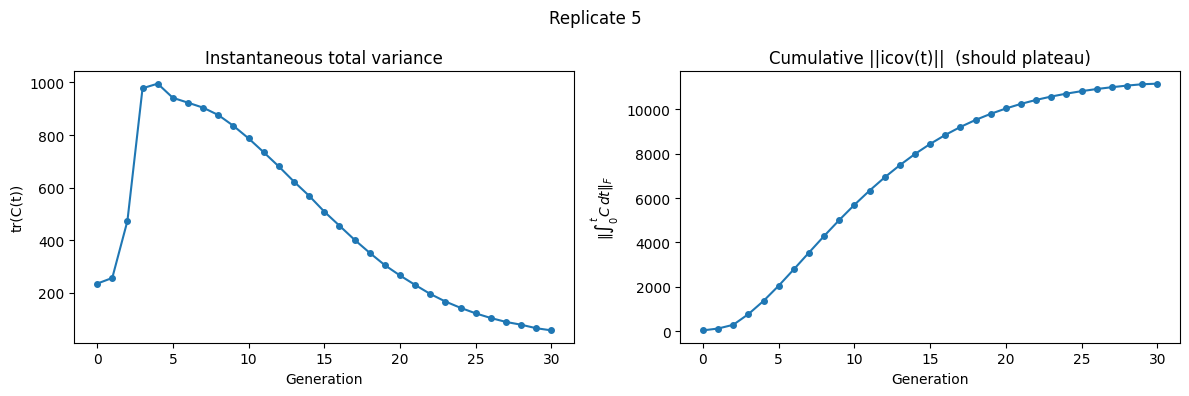

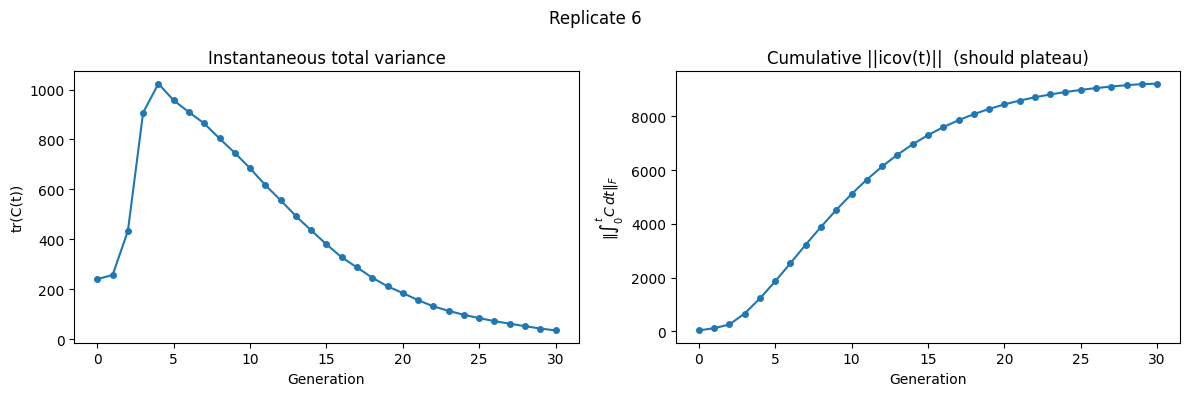


Dataset: BG505  |  get_simulation_results, method=fullcov
Running layer 12...
  Layer 12: running simulation...
  Layer 12: simulation ran for 30 saved generations.
  Layer 12: running inference...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...


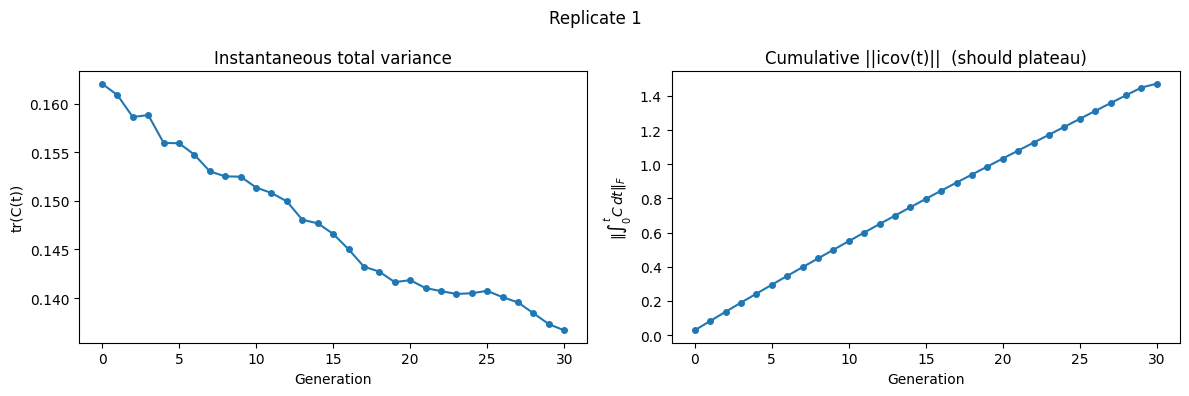

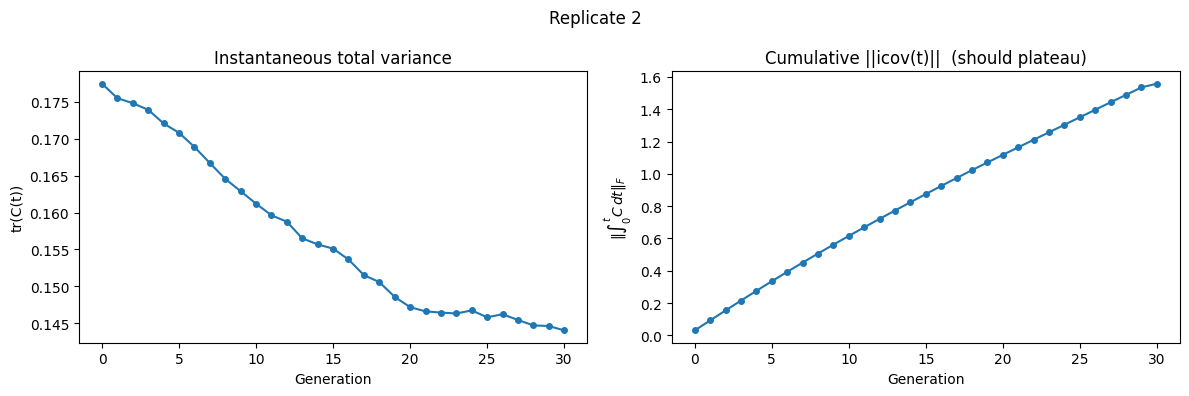

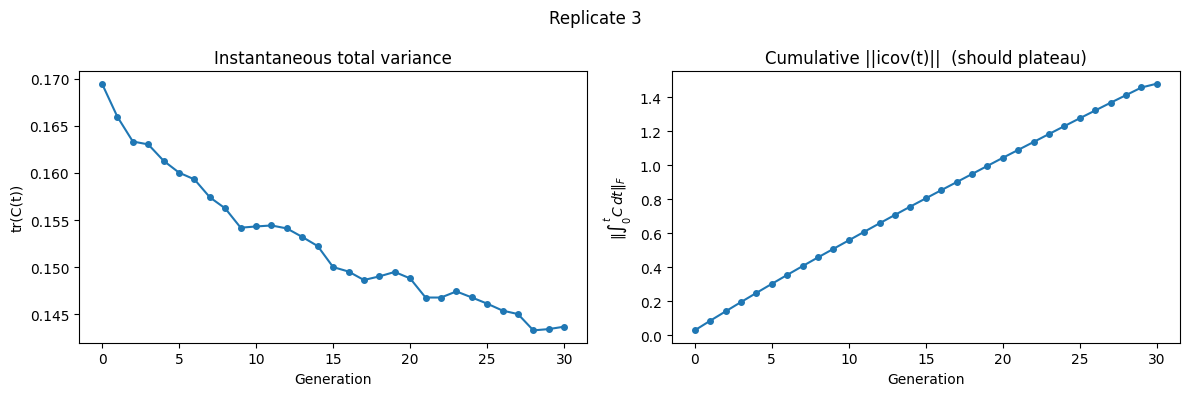

Running layer 18...
  Layer 18: running simulation...
  Layer 18: simulation ran for 30 saved generations.
  Layer 18: running inference...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...


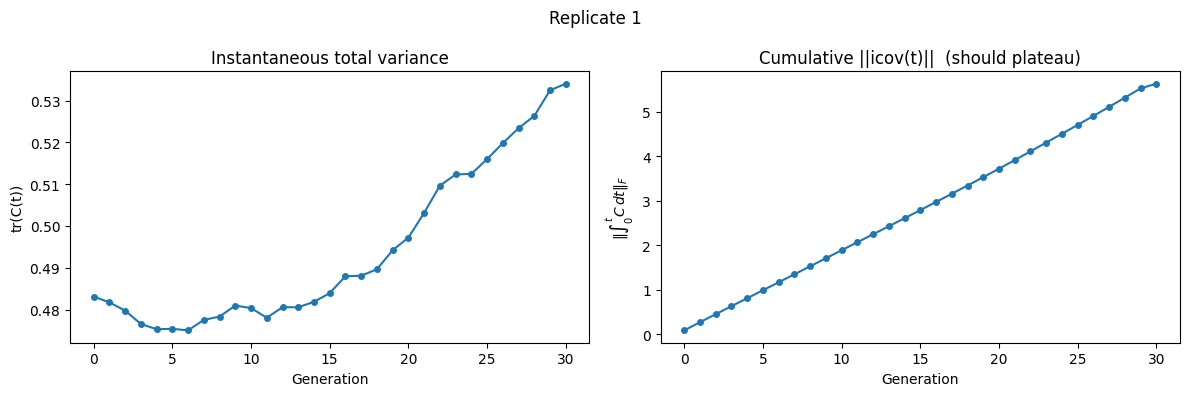

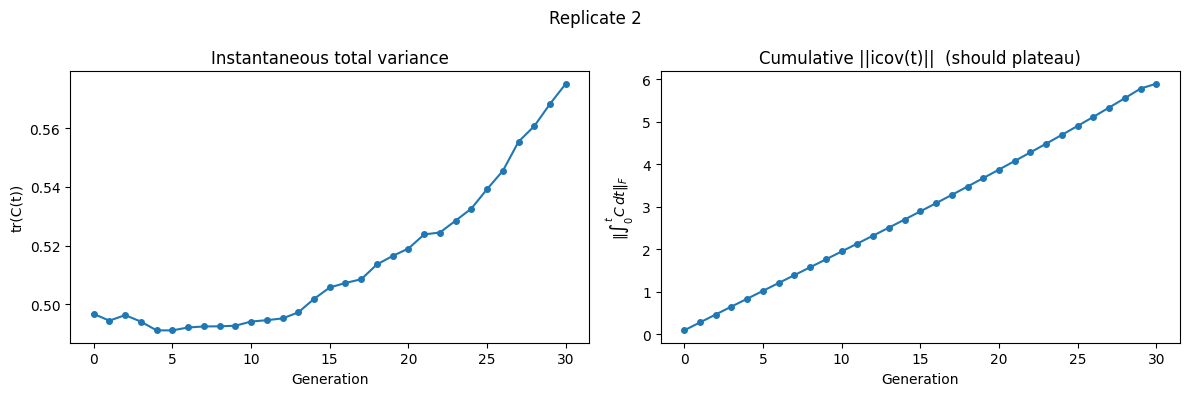

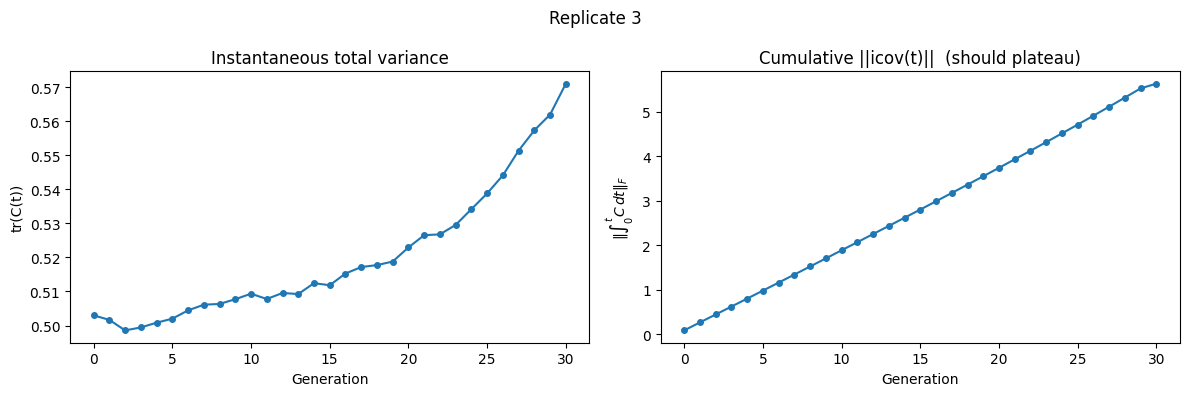


Dataset: BF520  |  get_simulation_results, method=fullcov
Running layer 12...
  Layer 12: running simulation...
  Layer 12: simulation ran for 30 saved generations.
  Layer 12: running inference...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...


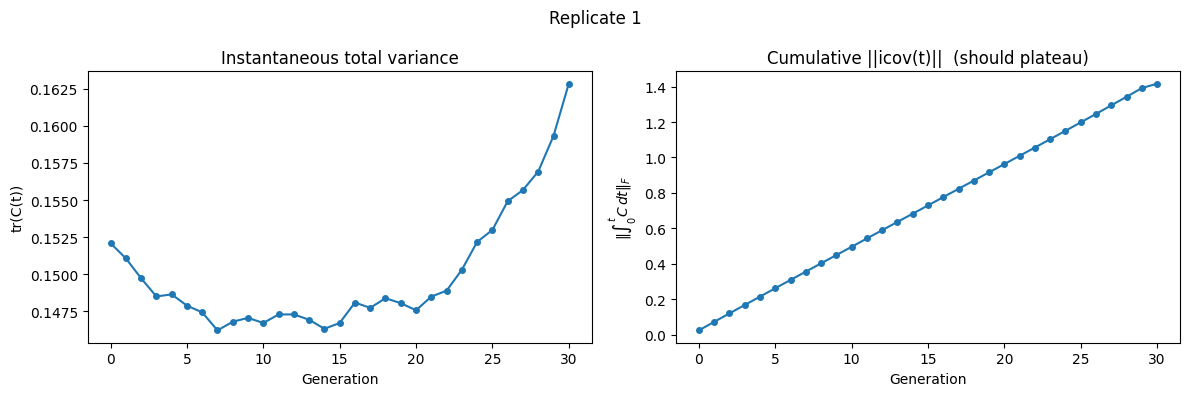

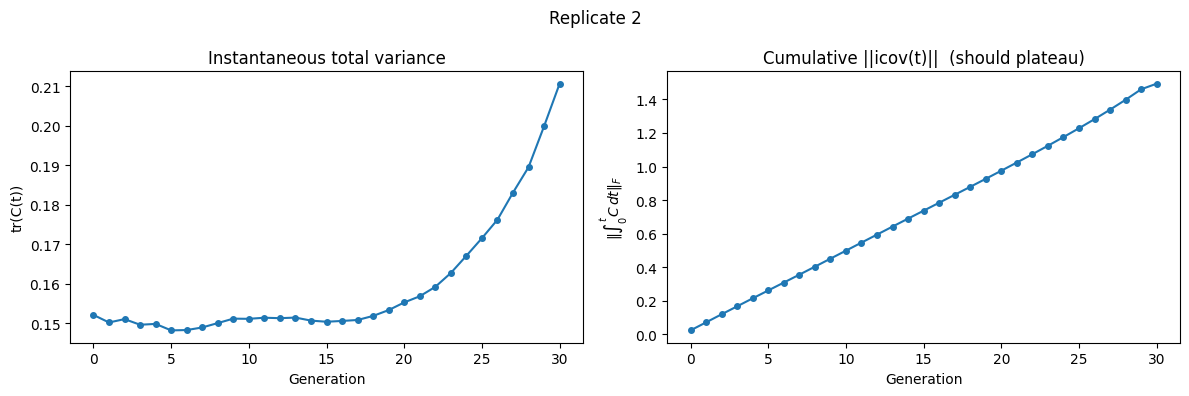

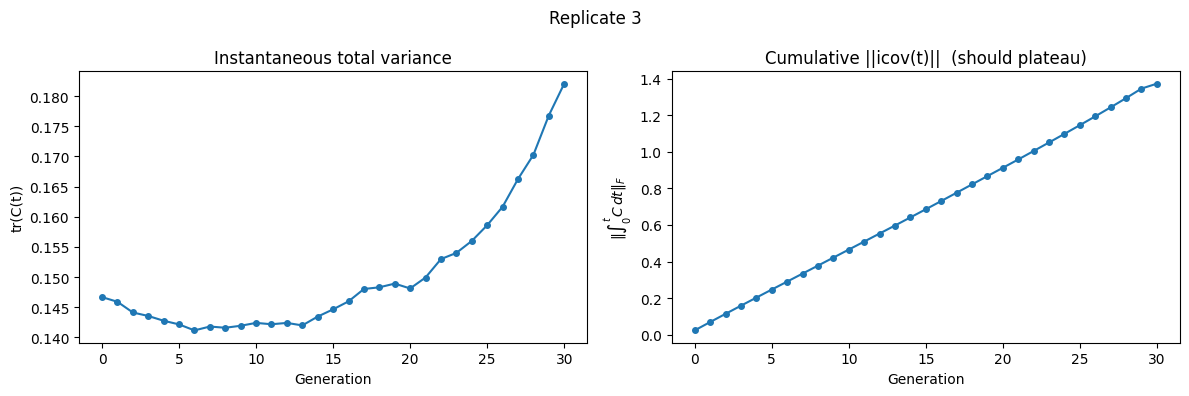

Running layer 18...
  Layer 18: running simulation...
  Layer 18: simulation ran for 30 saved generations.
  Layer 18: running inference...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...


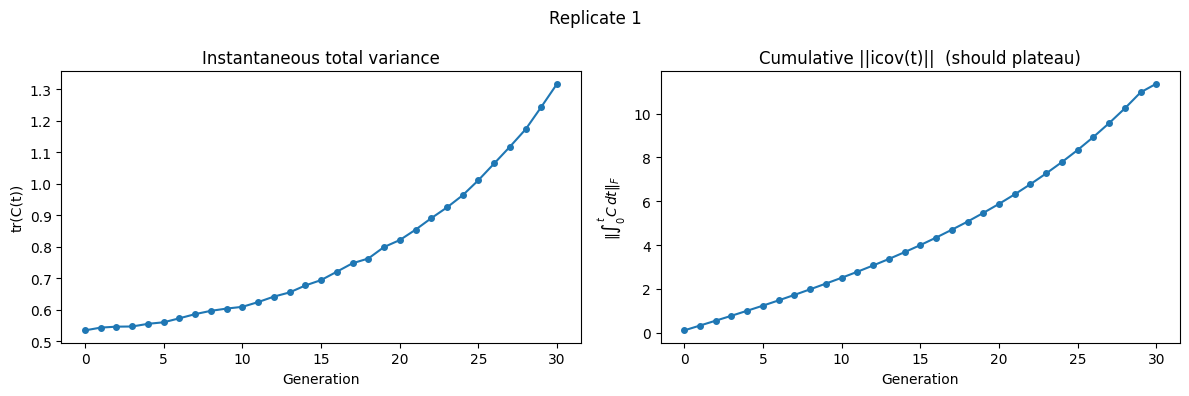

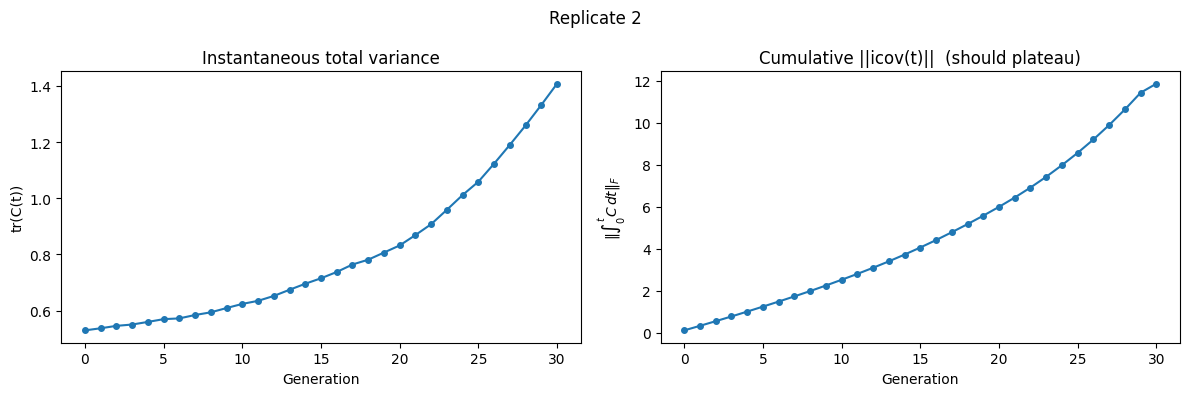

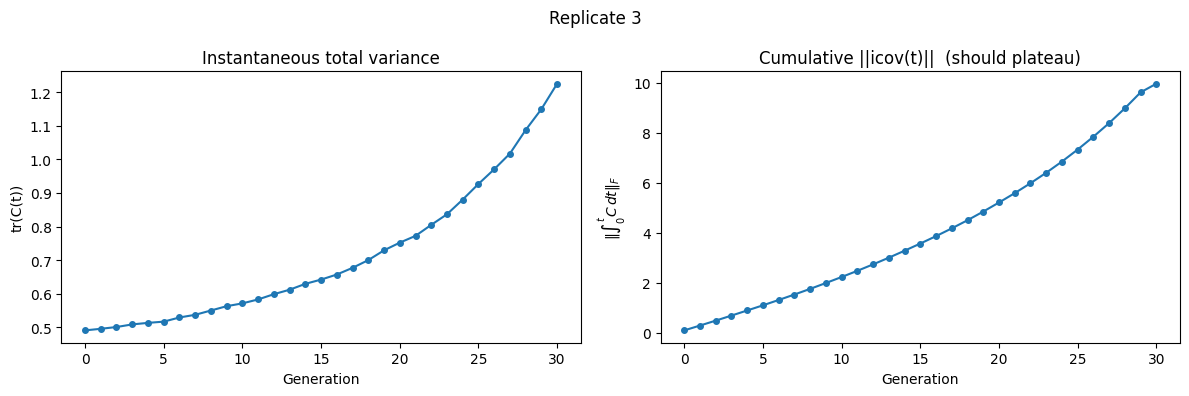


Done. Datasets completed: ['comb', 'BG505', 'BF520']


In [4]:

# Full covariance matrix method seems to be the best

PATHS = {
    "comb":  comb_path,
    "BG505": bg_path,
    "BF520": bf_path,
}


all_results_fullcov = {}

for path_name, path in PATHS.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {path_name}  |  get_simulation_results, method=fullcov")
    print('='*60)

    res = get_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        calc_error_bars=True,
        infer_ignored_dims=INFER_IGNORED,
        method="fullcov",
    )
    all_results_fullcov[path_name] = res  
print("\nDone. Datasets completed:", list(all_results_fullcov.keys()))

In [ ]:
# save the fullcov data for later analysis
pwd = "/Users/dylanwells/popDMS/esmDMS"
save_dir = pwd + "/esm_sim_saves"
output_file = "fullcov_all_results_cov_mats_opt.pkl"

output_path = os.path.join(save_dir, output_file)

with open(output_path, "wb") as f:
    pickle.dump(all_results_fullcov, f)
print(f"\nFull covariance method all results saved to {output_path}")

In [3]:
# load the fullcov data for later analysis
pwd = "/Users/dylanwells/popDMS/esmDMS"
save_dir = pwd + "/esm_sim_saves"
input_file = "fullcov_all_results_cov_mats_opt.pkl"
input_path = os.path.join(save_dir, input_file)
with open(input_path, "rb") as f:
    all_results_fullcov = pickle.load(f)
print(f"Full covariance method all results loaded from {input_path}")

Full covariance method all results loaded from /Users/dylanwells/popDMS/esmDMS/esm_sim_saves/fullcov_all_results_cov_mats_opt.pkl


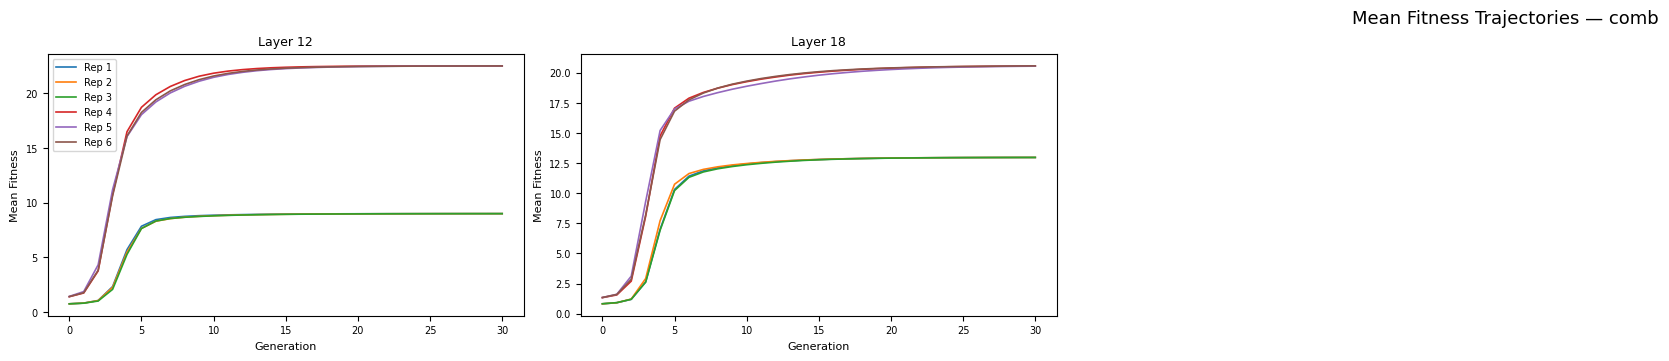

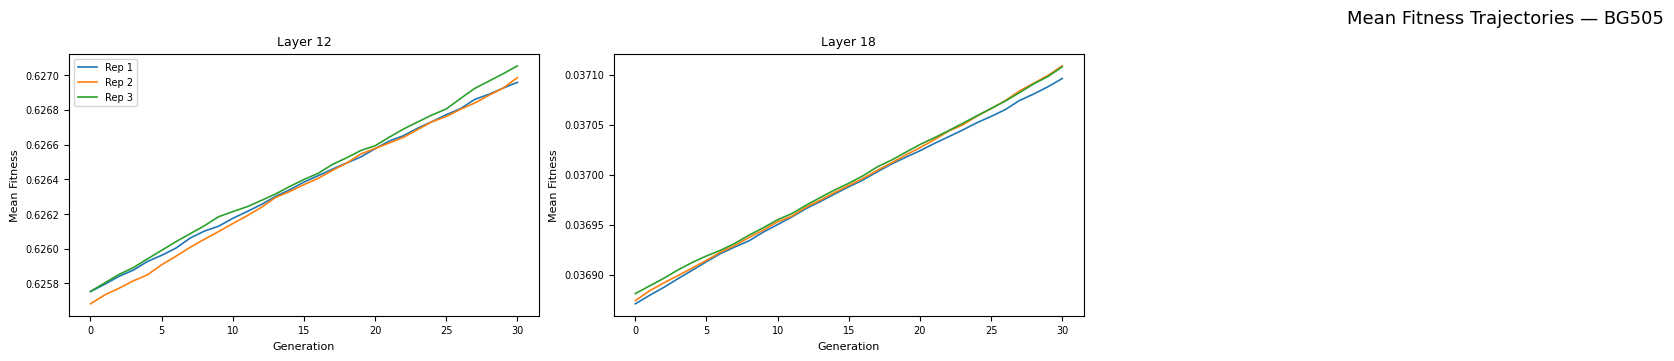

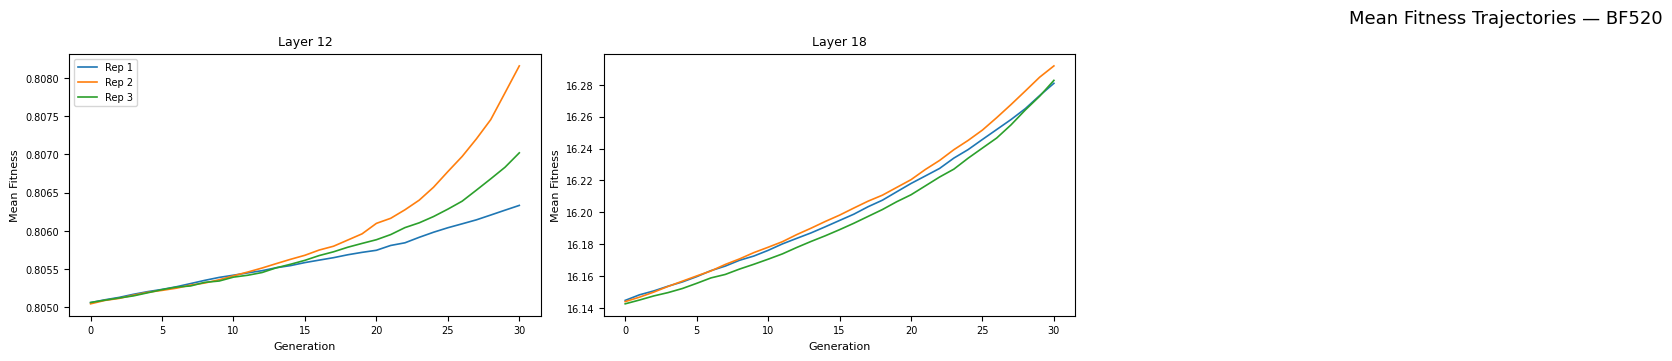

In [5]:
N_COLS = 6  # subplots per row

for path_name, res in all_results_fullcov.items():
    layers = sorted(res[4].keys())
    n_layers = len(layers)
    n_rows = int(np.ceil(n_layers / N_COLS))

    fig, axes = plt.subplots(n_rows, N_COLS,
                             figsize=(5 * N_COLS, 3.5 * n_rows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    for ax_idx, layer in enumerate(layers):
        ax = axes[ax_idx]
        generation_counts = res[4][layer]
        layer_fits = res[0][layer]
        n_reps = len(generation_counts[0])

        for rep in range(n_reps):
            gen_counts_rep = [gen_counts[rep] for gen_counts in generation_counts]
            rep_mean_fits = []
            for gen_counts in gen_counts_rep:
                total_count = np.sum(gen_counts)
                if total_count > 0:
                    freqs = gen_counts / total_count
                    rep_mean_fits.append(np.sum(freqs * layer_fits))
                else:
                    rep_mean_fits.append(0.0)
            ax.plot(rep_mean_fits, lw=1.2, label=f"Rep {rep+1}")

        ax.set_title(f"Layer {layer}", fontsize=9)
        ax.set_xlabel("Generation", fontsize=8)
        ax.set_ylabel("Mean Fitness", fontsize=8)
        ax.tick_params(labelsize=7)
        if ax_idx == 0:
            ax.legend(fontsize=7)

    for ax in axes[n_layers:]:
        ax.set_visible(False)

    fig.suptitle(f"Mean Fitness Trajectories — {path_name}", fontsize=13)
    plt.show()

In [6]:
# ── Helper functions for fitness analysis

FITNESS_FN = 'exp'  # must match the fitness function used in get_simulation_results
NCOLS = 6           # layers per row within grid figures


def get_embeddings(dataset_name, layer):
    """Load raw embeddings for a given dataset and layer."""
    df = load_final_df(layer, PATHS[dataset_name])
    return np.vstack(df['Embedding'].tolist())  # (N, D)


def inferred_fitness(embeddings, sel_coefs, fitness_fn='exp'):
    """Fitness of each variant given raw embeddings and selection coefficients.
    
    embeddings : (N, D)
    sel_coefs  : (D,)
    returns    : (N,)
    """
    dot = embeddings @ sel_coefs
    if fitness_fn == 'exp':
        return np.exp(dot)
    elif fitness_fn == 'plus1':
        return np.maximum(1.0 + dot, 0.0)
    else:
        raise ValueError(f"Unknown fitness function: {fitness_fn}")


def _scatter_panel(ax, true_z, inf_z, title, color='steelblue'):
    """Scatter plot with diagonal reference line and Pearson r annotation."""
    r, _ = pearsonr(true_z, inf_z)
    ax.scatter(true_z, inf_z, alpha=0.4, s=8, color=color, rasterized=True)
    lo = min(true_z.min(), inf_z.min()) - 0.3
    hi = max(true_z.max(), inf_z.max()) + 0.3
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=0.8)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('True fitness (z)', fontsize=7)
    ax.set_ylabel('Inferred fitness (z)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
                ha='left', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85))
    return r

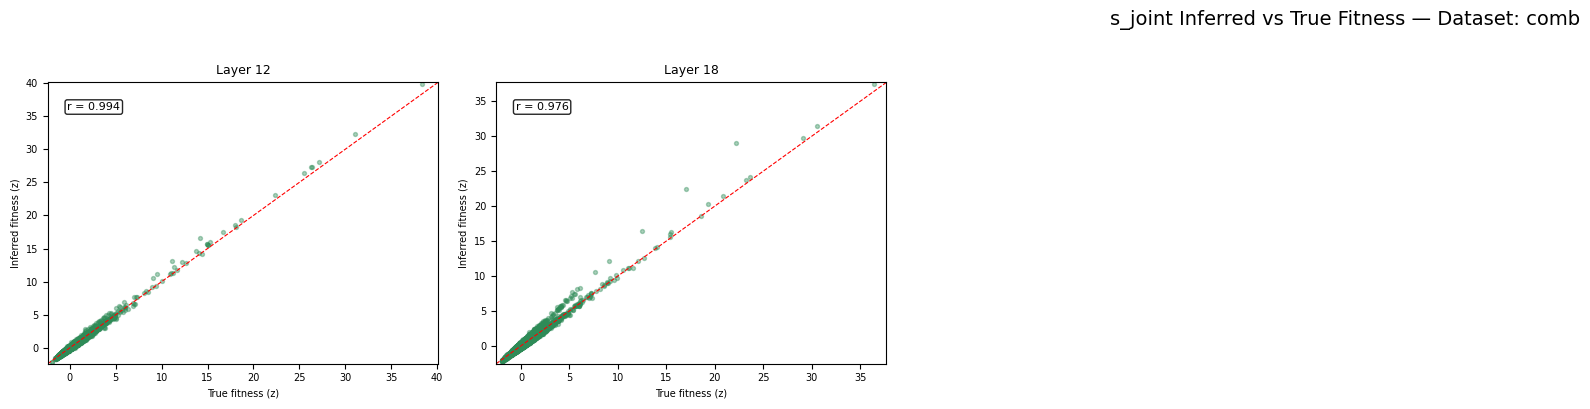

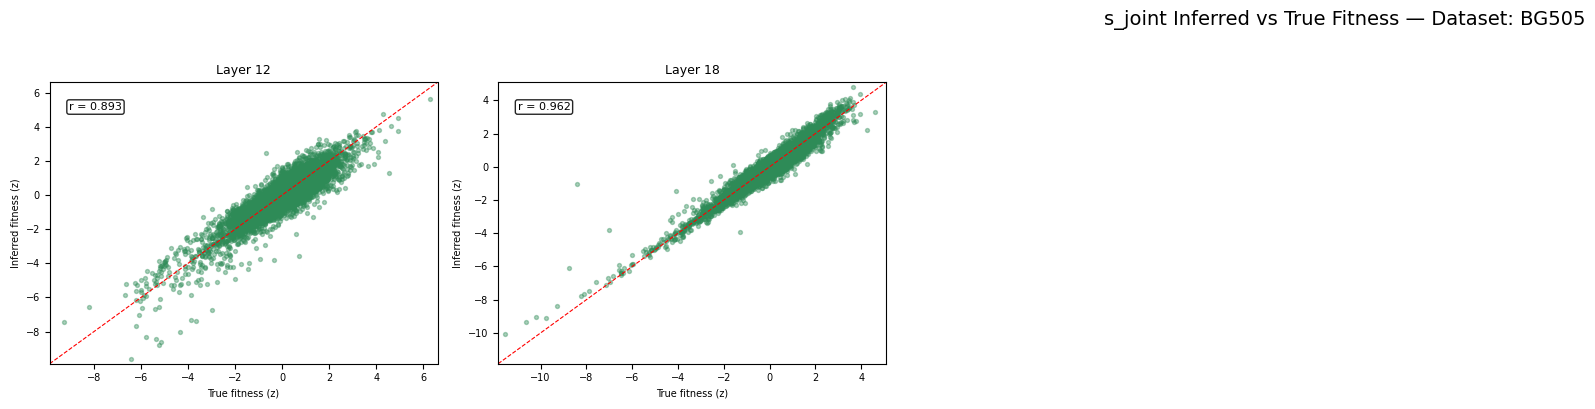

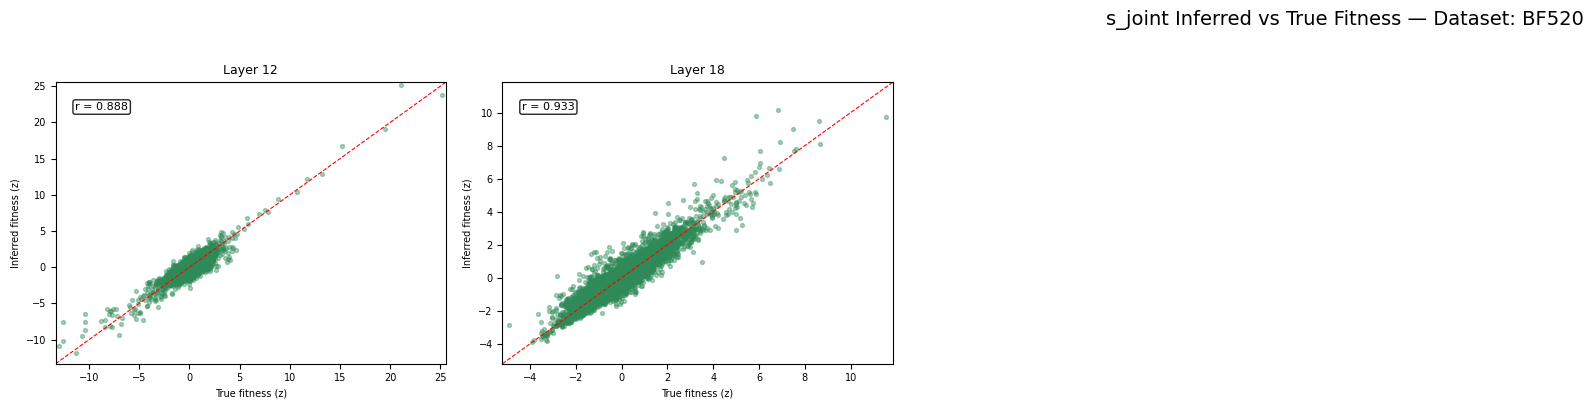

In [7]:
# ── Per-layer s_joint inferred fitness vs true fitness
# One figure per dataset; all layers tiled in a NCOLS-column grid.
for dataset in all_results_fullcov:
    sim_data         = all_results_fullcov[dataset]
    all_layer_fits   = sim_data[0]
    detailed_results = sim_data[2]

    layers_available = sorted(detailed_results.keys())
    n_layers = len(layers_available)
    nrows    = (n_layers + NCOLS - 1) // NCOLS

    fig, axes = plt.subplots(nrows, NCOLS,
                              figsize=(4.5 * NCOLS, 4 * nrows),
                              squeeze=False)
    fig.suptitle(
        f's_joint Inferred vs True Fitness — Dataset: {dataset}',
        fontsize=14, y=1.01
    )

    for idx, layer in enumerate(layers_available):
        row, col = divmod(idx, NCOLS)
        ax = axes[row, col]

        true_z  = z_normalize(np.array(all_layer_fits[layer]))
        s_joint = detailed_results[layer][1]             # (D,)
        emb     = get_embeddings(dataset, layer)         # (N, D)
        inf_z   = z_normalize(inferred_fitness(emb, s_joint, FITNESS_FN))

        _scatter_panel(ax, true_z, inf_z, title=f'Layer {layer}', color='seagreen')

    for idx in range(n_layers, nrows * NCOLS):
        row, col = divmod(idx, NCOLS)
        axes[row, col].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'fitness_scatter_sjoint_{dataset}.png', dpi=80, bbox_inches='tight')
    plt.show()

## Inference quality vs simulation progress

Does the correlation between inferred and true fitness depend on how far the simulation had evolved when we cut it off?

For each layer, we compute two quantities:
- **Pearson $r$**: correlation between inferred and true fitness (z-normalized)
- **End-slope**: the slope of the mean-fitness trajectory over the last 5 generations, estimated by linear regression. A steep slope means the simulation was still actively selecting; a flat slope means it had plateaued.

In [8]:
from scipy.stats import linregress

# ── Configuration ─────────────────────────────────────────────────────────────
# Set to a subset of dataset names to analyze only those, e.g. ['BG505']
# or leave as None to include all datasets in all_results_fullcov
DATASETS_TO_ANALYZE = None   # e.g. ['BG505'] or ['comb', 'BF520'] or None

END_WINDOW = 10   # generations to use for the end-growth estimate

# ─────────────────────────────────────────────────────────────────────────────

def mean_fitness_trajectory(generation_counts, layer_fits):
    """Return the mean-over-reps fitness trajectory: shape (n_gens,)."""
    n_reps = len(generation_counts[0])
    traj_by_rep = []
    for rep in range(n_reps):
        rep_traj = []
        for gen_counts in generation_counts:
            counts = gen_counts[rep]
            total = counts.sum()
            rep_traj.append((counts / total) @ layer_fits if total > 0 else 0.0)
        traj_by_rep.append(rep_traj)
    return np.mean(traj_by_rep, axis=0)   # (n_gens,)


def end_growth_fraction(traj, window=END_WINDOW):
    """Fraction of total fitness gain that occurred in the last `window` gens.

    = (traj[-1] - traj[-window]) / (traj[-1] - traj[0])

    Interpretation:
      ~0  → simulation had plateaued; last few gens added little
      ~1  → all growth happened at the very end; still actively selecting
    """
    total_gain = traj[-1] - traj[0]
    if abs(total_gain) < 1e-12:
        return 0.0
    return (traj[-1] - traj[-window]) / total_gain


# ── Collect metrics ───────────────────────────────────────────────────────────
active_datasets = DATASETS_TO_ANALYZE or list(all_results_fullcov.keys())

records = []
for dataset in active_datasets:
    sim_data         = all_results_fullcov[dataset]
    all_layer_fits   = sim_data[0]
    detailed_results = sim_data[2]
    gen_counts_all   = sim_data[4]

    for layer in sorted(detailed_results.keys()):
        layer_fits = np.array(all_layer_fits[layer])

        # Pearson r
        true_z  = z_normalize(layer_fits)
        s_joint = detailed_results[layer][1]
        emb     = get_embeddings(dataset, layer)
        inf_z   = z_normalize(inferred_fitness(emb, s_joint, FITNESS_FN))
        r, _    = pearsonr(true_z, inf_z)

        # Fitness trajectory & growth metrics
        traj       = mean_fitness_trajectory(gen_counts_all[layer], layer_fits)
        end_frac   = end_growth_fraction(traj, window=END_WINDOW)
        fit_range  = float(traj[-1] - traj[0])

        records.append(dict(
            dataset=dataset, layer=layer,
            pearson_r=r,
            end_frac=end_frac,
            fit_range=fit_range,
            traj=traj,
        ))

df_metrics = pd.DataFrame(records)
print(df_metrics[['dataset', 'layer', 'pearson_r', 'end_frac', 'fit_range']].to_string(index=False))

dataset  layer  pearson_r  end_frac  fit_range
   comb     12   0.994298  0.001635  14.653410
   comb     18   0.976490  0.006625  15.682570
  BG505     12   0.893484  0.295403   0.001268
  BG505     18   0.961541  0.305739   0.000229
  BF520     12   0.887684  0.565566   0.002114
  BF520     18   0.933104  0.446379   0.141443


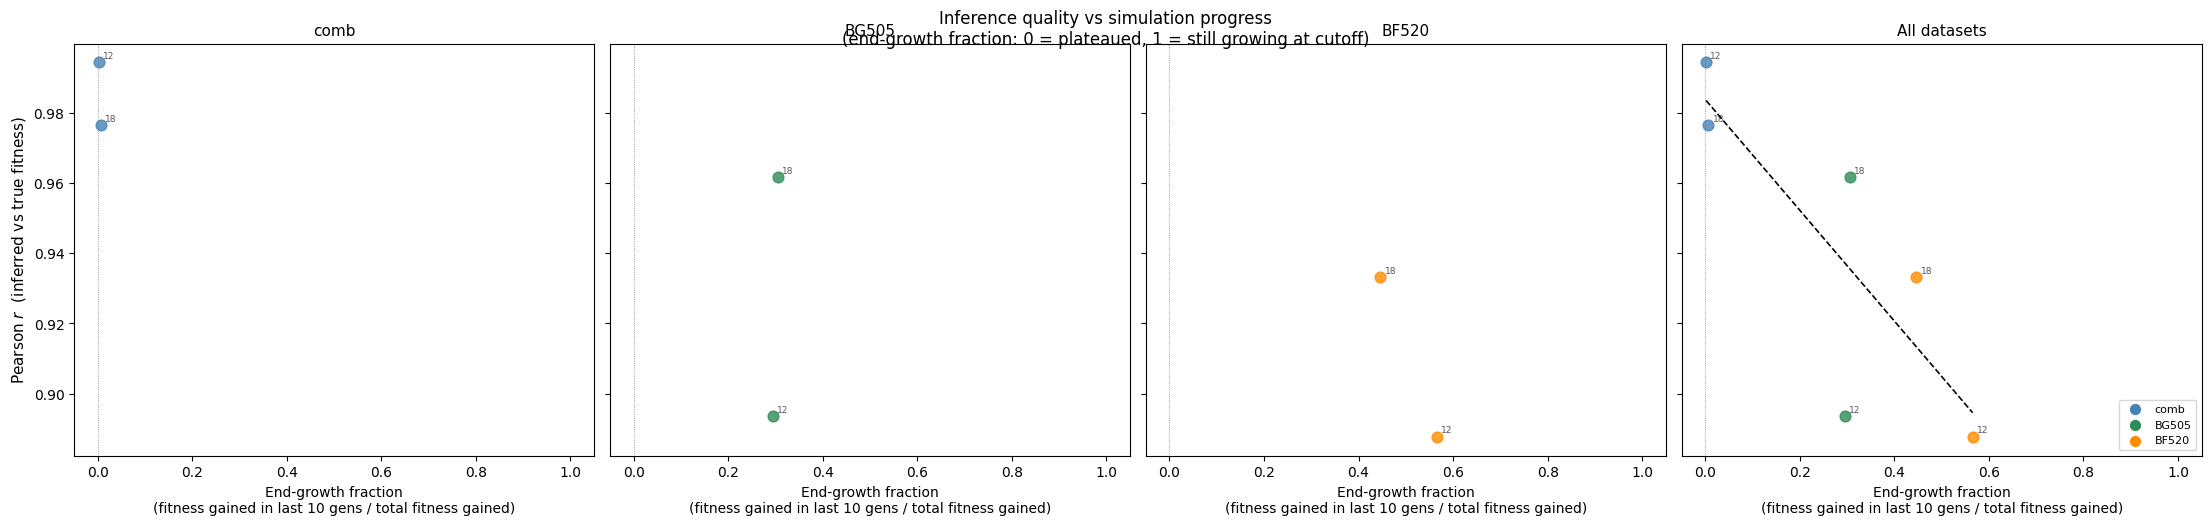

In [9]:
DATASET_COLORS = {'comb': 'steelblue', 'BG505': 'seagreen', 'BF520': 'darkorange'}

datasets_present = df_metrics['dataset'].unique().tolist()
n_ds = len(datasets_present)

n_panels = n_ds + (1 if n_ds > 1 else 0)
fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5),
                          constrained_layout=True, sharey=True)
if n_panels == 1:
    axes = [axes]

def _draw_panel(ax, sub_df, title, color_by_dataset=False):
    for _, row in sub_df.iterrows():
        color = DATASET_COLORS.get(row['dataset'], 'gray') if color_by_dataset \
                else DATASET_COLORS.get(row['dataset'], 'steelblue')
        ax.scatter(row['end_frac'], row['pearson_r'],
                   color=color, alpha=0.8, s=60, zorder=3)
        ax.annotate(str(int(row['layer'])),
                    (row['end_frac'], row['pearson_r']),
                    fontsize=6.5, alpha=0.65,
                    xytext=(3, 3), textcoords='offset points')

    x = sub_df['end_frac'].values
    y = sub_df['pearson_r'].values
    if len(x) > 2:
        res = linregress(x, y)
        xs  = np.linspace(x.min(), x.max(), 200)
        r_overall = pearsonr(x, y)[0]
        ax.plot(xs, res.slope * xs + res.intercept, 'k--',
                linewidth=1.2, zorder=2, label=f'r = {r_overall:.2f}')
        ax.legend(fontsize=9, loc='lower right')

    ax.set_xlim(-0.05, 1.05)
    ax.axvline(0, color='gray', linewidth=0.6, linestyle=':')
    ax.set_xlabel(f'End-growth fraction\n'
                  f'(fitness gained in last {END_WINDOW} gens / total fitness gained)',
                  fontsize=10)
    ax.set_title(title, fontsize=11)

for i, ds in enumerate(datasets_present):
    _draw_panel(axes[i], df_metrics[df_metrics['dataset'] == ds], title=ds)

if n_ds > 1:
    _draw_panel(axes[-1], df_metrics, title='All datasets', color_by_dataset=True)
    handles = [plt.scatter([], [], color=DATASET_COLORS.get(ds, 'gray'), s=50, label=ds)
               for ds in datasets_present]
    axes[-1].legend(handles=handles, fontsize=8, loc='lower right')

axes[0].set_ylabel('Pearson $r$  (inferred vs true fitness)', fontsize=11)

fig.suptitle(
    'Inference quality vs simulation progress\n'
    '(end-growth fraction: 0 = plateaued, 1 = still growing at cutoff)',
    fontsize=12, y=1.02
)
plt.savefig('inference_vs_end_growth_fraction.png', dpi=100, bbox_inches='tight')
plt.show()

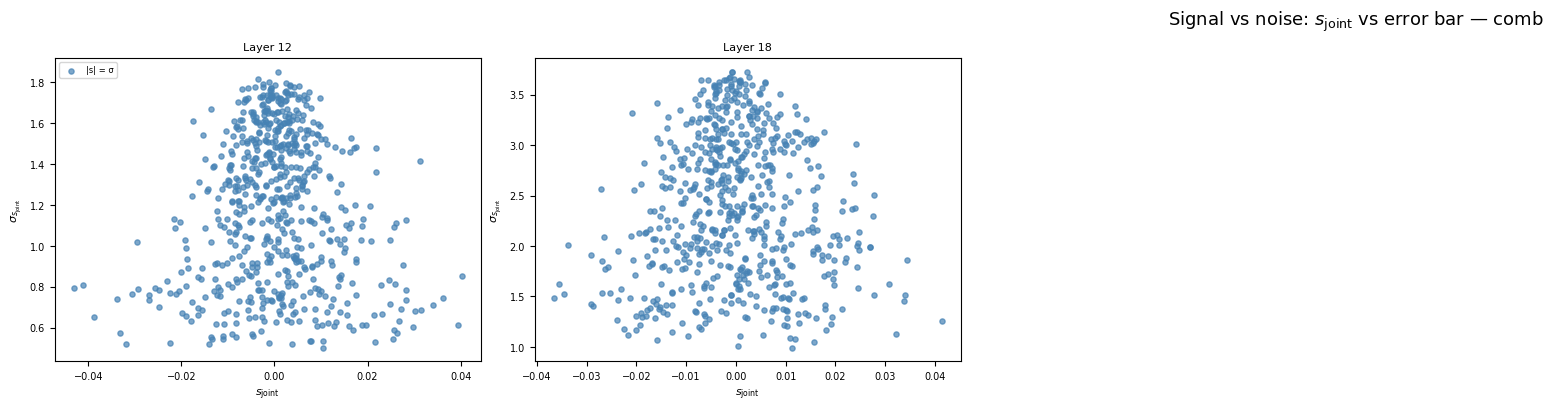

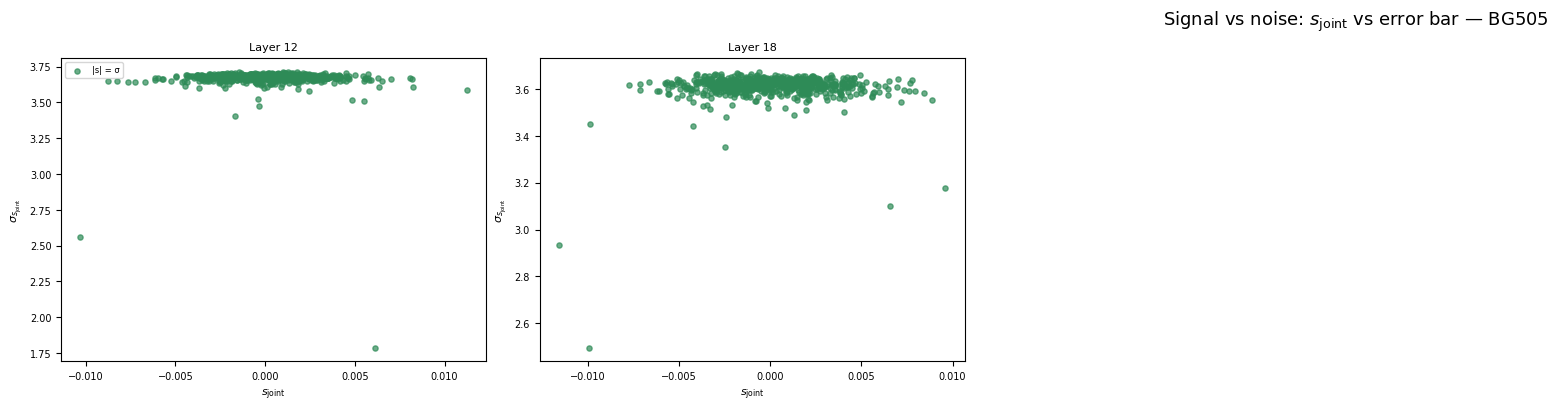

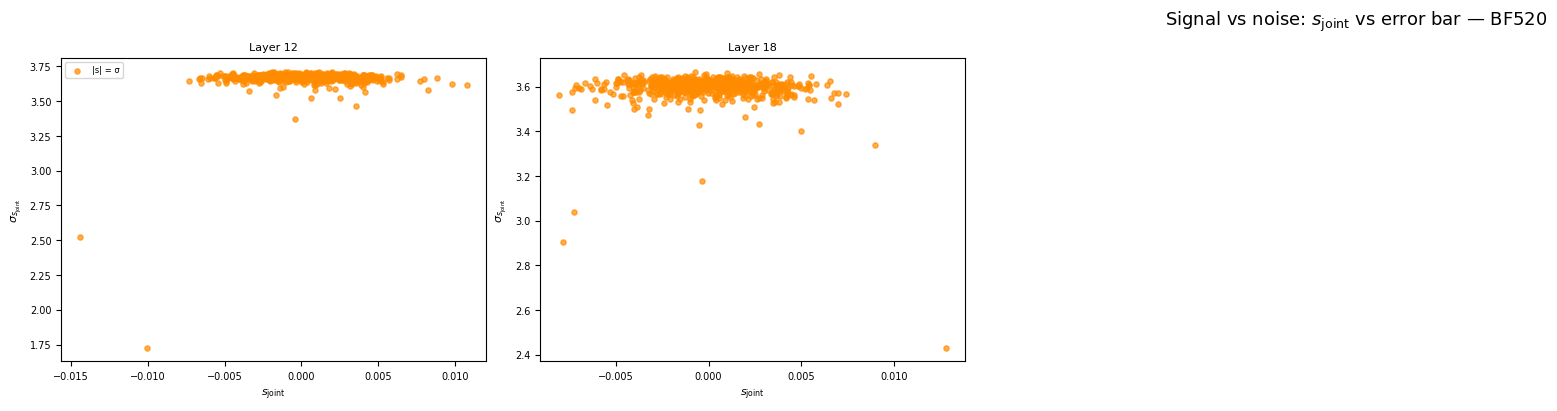

In [10]:
NCOLS_EB = 6   # panels per row

for dataset in active_datasets:
    sim_data         = all_results_fullcov[dataset]
    detailed_results = sim_data[2]
    layers           = sorted(detailed_results.keys())

    n_layers = len(layers)
    nrows    = (n_layers + NCOLS_EB - 1) // NCOLS_EB
    color    = DATASET_COLORS.get(dataset, 'steelblue')

    fig, axes = plt.subplots(nrows, NCOLS_EB,
                              figsize=(4.5 * NCOLS_EB, 4 * nrows),
                              constrained_layout=True)
    axes = np.array(axes).flatten()

    for idx, layer in enumerate(layers):
        ax = axes[idx]
        res = detailed_results[layer]
        s_joint        = np.array(res[1])   # (D,)
        s_joint_errors = res[3]             # (D,) or None

        #print(f"s_joint layer {layer}: {s_joint}")
        #print(f"s_joint_errors layer {layer}: {s_joint_errors}")


        s_joint_errors = np.array(s_joint_errors)
        ax.scatter(s_joint, s_joint_errors, color=color, alpha=0.7, s=14, zorder=3)
        #hi = max(np.abs(s_joint).max(), s_joint_errors.max()) * 1.1
        #ax.plot([-hi, hi], [0, hi], 'r--', linewidth=0.8, zorder=4)
        ax.set_title(f'Layer {layer}', fontsize=8)
        ax.set_xlabel('$s_\\mathrm{joint}$', fontsize=8)
        ax.set_ylabel('$\\sigma_{s_\\mathrm{joint}}$', fontsize=8
        )
        ax.tick_params(labelsize=7)
        if idx == 0:
            ax.legend(['|s| = σ', ''], fontsize=6, loc='upper left')
    for idx in range(n_layers, len(axes)):
        axes[idx].set_visible(False)
    fig.suptitle(
        f'Signal vs noise: $s_\\mathrm{{joint}}$ vs error bar — {dataset}',
        fontsize=13
    )
    #plt.savefig(f'sjoint_vs_errorbars_{dataset}.png', dpi=80, bbox_inches='tight')
    plt.show()



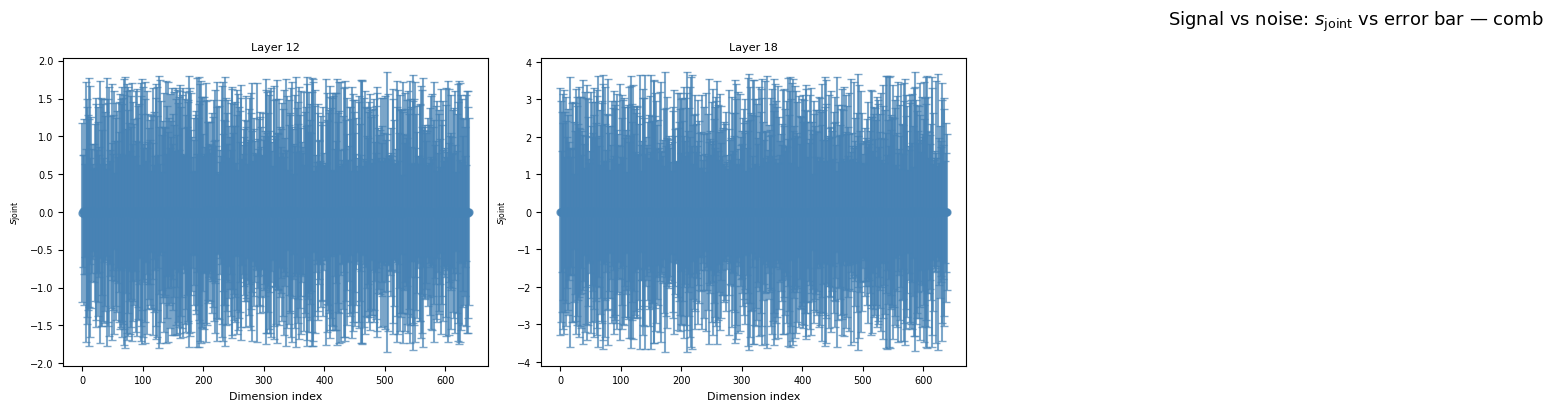

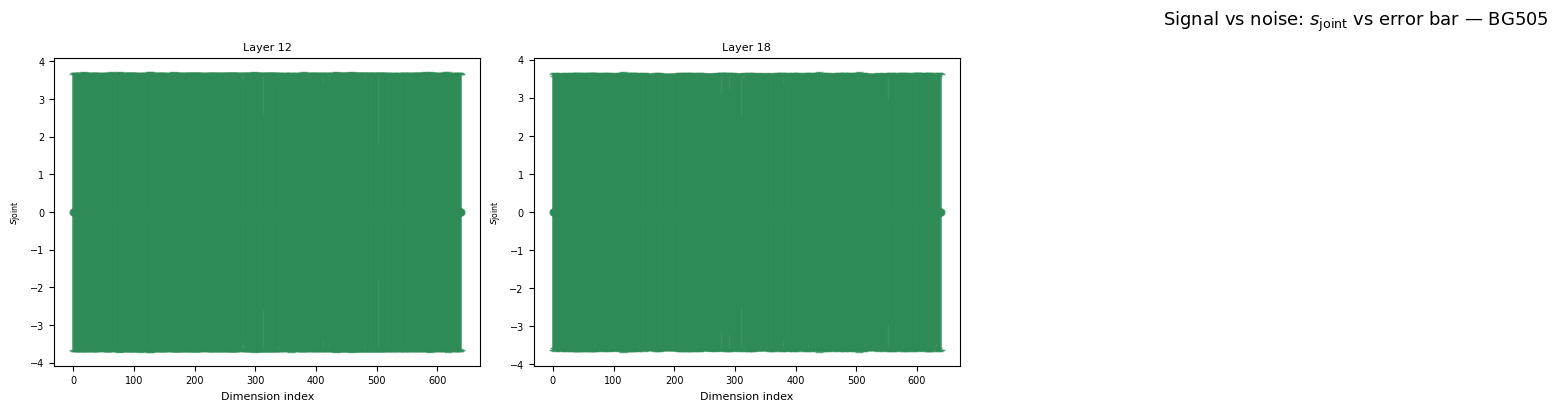

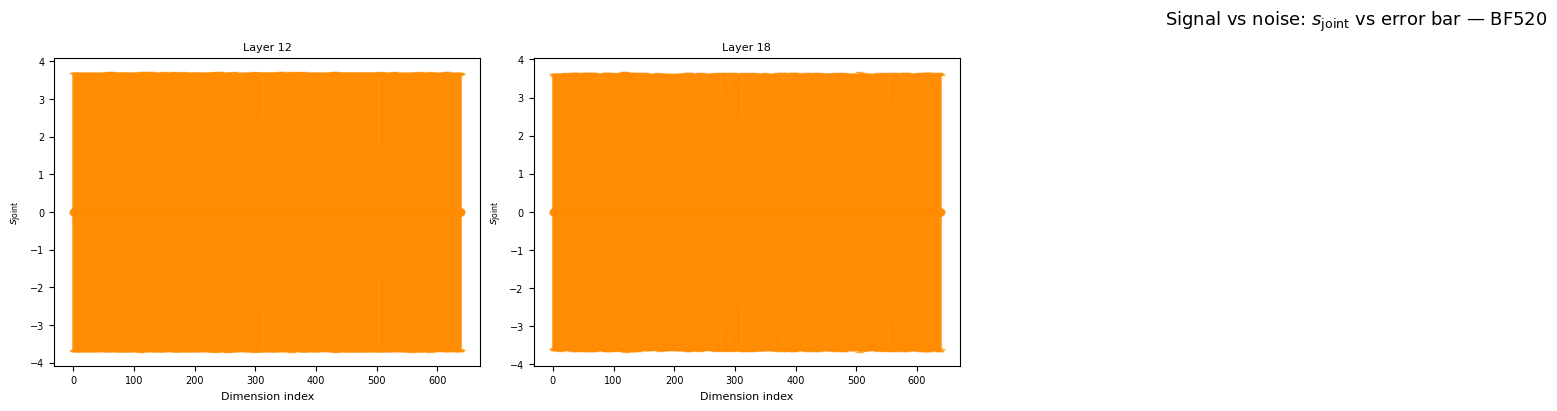

In [11]:
NCOLS_EB = 6   # panels per row

for dataset in active_datasets:
    sim_data         = all_results_fullcov[dataset]
    detailed_results = sim_data[2]
    layers           = sorted(detailed_results.keys())

    n_layers = len(layers)
    nrows    = (n_layers + NCOLS_EB - 1) // NCOLS_EB
    color    = DATASET_COLORS.get(dataset, 'steelblue')

    fig, axes = plt.subplots(nrows, NCOLS_EB,
                              figsize=(4.5 * NCOLS_EB, 4 * nrows),
                              constrained_layout=True)
    axes = np.array(axes).flatten()

    for idx, layer in enumerate(layers):
        ax = axes[idx]
        res = detailed_results[layer]
        s_joint        = np.array(res[1])   # (D,)
        s_joint_errors = res[3]             # (D,) or None

        #print(f"s_joint layer {layer}: {s_joint}")
        #print(f"s_joint_errors layer {layer}: {s_joint_errors}")


        s_joint_errors = np.array(s_joint_errors)
        x = range(len(s_joint))
        y = s_joint
        yerr = s_joint_errors
        ax.errorbar(x, y, yerr=yerr, fmt='o', color=color, alpha=0.7, markersize=5, capsize=3, zorder=3)
        #hi = max(np.abs(s_joint).max(), s_joint_errors.max()) * 1.1
        #ax.plot([-hi, hi], [0, hi], 'r--', linewidth=0.8, zorder=4)
        ax.set_title(f'Layer {layer}', fontsize=8)
        ax.set_xlabel('Dimension index', fontsize=8)
        ax.set_ylabel('$s_\\mathrm{joint}$', fontsize=8)
        ax.tick_params(labelsize=7)

    for idx in range(n_layers, len(axes)):
        axes[idx].set_visible(False)
    fig.suptitle(
        f'Signal vs noise: $s_\\mathrm{{joint}}$ vs error bar — {dataset}',
        fontsize=13
    )
    #plt.savefig(f'sjoint_vs_errorbars_{dataset}.png', dpi=80, bbox_inches='tight')
    plt.show()

